# Customer Churn Prediction

**Business question:** which customers of a fintech remittance app are likely to churn (stop sending transfers), and which factors drive that risk?

**Definition of churn:** a customer who was previously active but sent no transfer in the last 60 days as of the reference date (`churned = 1`).

**Why this matters:** acquiring a new customer costs more than retaining one. If we can flag at-risk customers early and understand what's driving the risk, the retention team can act on it (a targeted offer, a support follow-up, a re-engagement message) before the customer is gone for good.

**Approach:** build a baseline interpretable model (logistic regression) and a stronger model (random forest), compare them with metrics that make sense for an imbalanced problem, and use feature importance to turn the model into retention recommendations, not just a prediction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42


## 1. Load and inspect the data

In [2]:
df = pd.read_csv("customer_churn_data.csv")
print(df.shape)
df.head()


(6000, 12)


,customer_id,tenure_months,avg_monthly_transactions,avg_transaction_amount_usd,days_since_last_transaction,support_tickets_last_90d,avg_satisfaction_score,used_promo_code,referred_by_friend,country,device,churned
0,501710,10,2.68,267.06,19,0,NaN,0,0,Mexico,iOS,0
1,502921,12,1.64,134.85,39,0,NaN,1,0,Colombia,Android,0
2,505660,24,9.79,431.44,38,3,7.4,0,0,Mexico,iOS,0
3,501371,11,5.23,256.59,49,0,NaN,0,0,Mexico,Android,0
4,503477,19,4.24,303.70,18,0,NaN,0,0,Colombia,iOS,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  6000 non-null   int64  
 1   tenure_months                6000 non-null   int64  
 2   avg_monthly_transactions     6000 non-null   float64
 3   avg_transaction_amount_usd   6000 non-null   float64
 4   days_since_last_transaction  6000 non-null   int64  
 5   support_tickets_last_90d     6000 non-null   int64  
 6   avg_satisfaction_score       2682 non-null   float64
 7   used_promo_code              6000 non-null   int64  
 8   referred_by_friend           6000 non-null   int64  
 9   country                      6000 non-null   str    
 10  device                       6000 non-null   str    
 11  churned                      6000 non-null   int64  
dtypes: float64(3), int64(7), str(2)
memory usage: 562.6 KB


In [4]:
df.isna().sum()


customer_id                       0
tenure_months                     0
avg_monthly_transactions          0
avg_transaction_amount_usd        0
days_since_last_transaction       0
support_tickets_last_90d          0
avg_satisfaction_score         3318
used_promo_code                   0
referred_by_friend                0
country                           0
device                            0
churned                           0
dtype: int64

`avg_satisfaction_score` is missing for customers who never contacted support, which makes sense: there's no satisfaction survey if there was never a support interaction. I'll handle this explicitly in feature engineering rather than just dropping rows or silently filling with the column mean, since "never contacted support" is itself meaningful information.

## 2. Exploratory data analysis

First thing to check on any churn problem: how imbalanced is the target? This matters a lot for which metrics are meaningful later.

Churn rate: 17.8%
Churned: 1067  |  Not churned: 4933


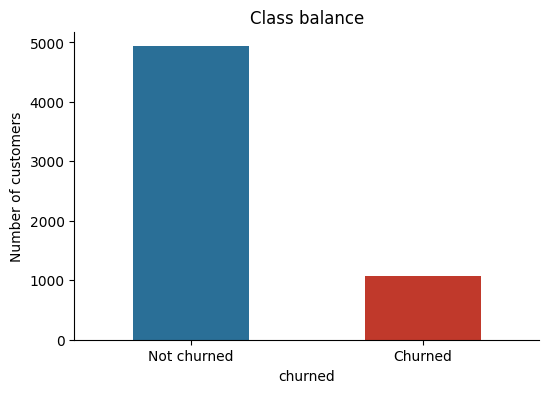

In [5]:
churn_rate = df["churned"].mean()
print(f"Churn rate: {churn_rate*100:.1f}%")
print(f"Churned: {df['churned'].sum()}  |  Not churned: {(df['churned']==0).sum()}")

df["churned"].value_counts().plot(kind="bar", color=["#2a6f97", "#c0392b"])
plt.xticks([0, 1], ["Not churned", "Churned"], rotation=0)
plt.ylabel("Number of customers")
plt.title("Class balance")
plt.show()


About 1 in 6 customers churned. This is imbalanced enough that a model could get ~82% accuracy just by predicting "not churned" for everyone, which would be a useless model. I'll keep this in mind and lean on precision, recall and ROC-AUC instead of accuracy alone.

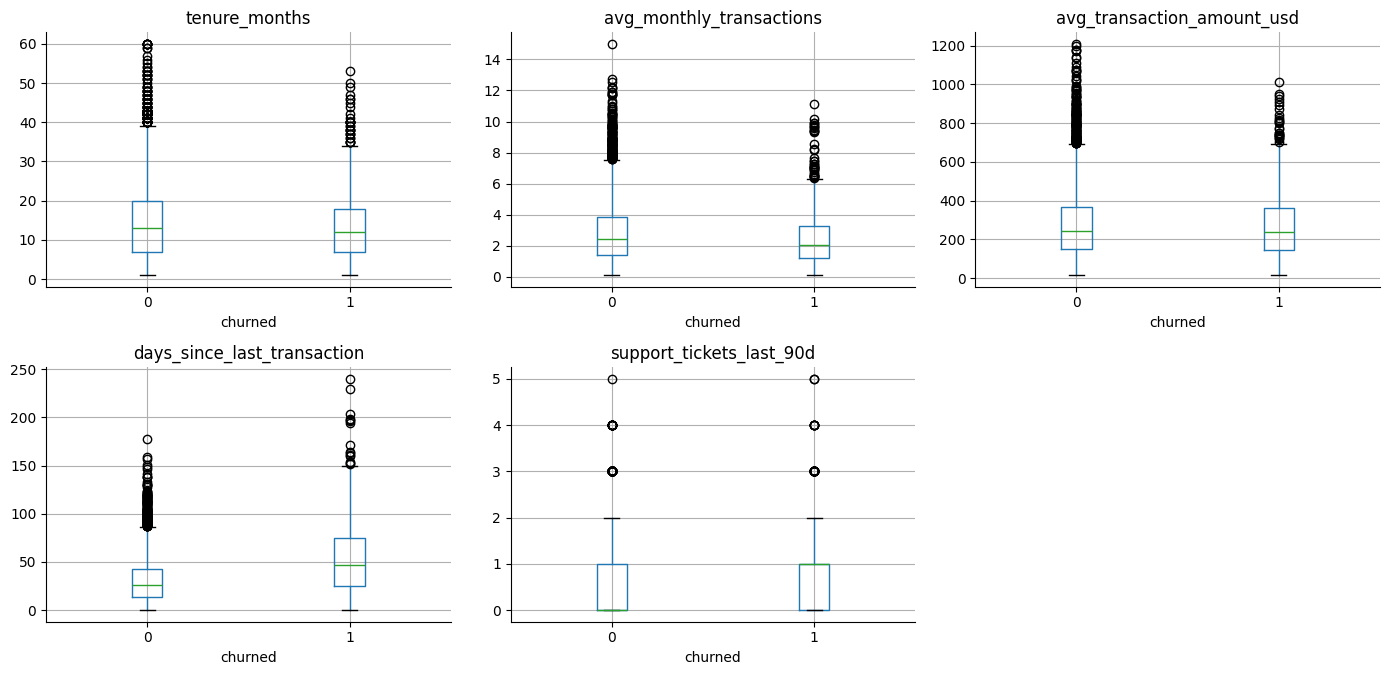

In [6]:
numeric_cols = ["tenure_months", "avg_monthly_transactions", "avg_transaction_amount_usd",
                "days_since_last_transaction", "support_tickets_last_90d"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by="churned", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("churned")
axes[-1].axis("off")
plt.suptitle("")
plt.tight_layout()
plt.show()


`days_since_last_transaction` and `support_tickets_last_90d` look like they separate the two groups the most: churned customers tend to have gone longer without a transfer and to have contacted support more. `tenure_months` and `avg_monthly_transactions` look lower for churned customers too, which fits the story (newer, less engaged customers churn more).

In [7]:
corr = df[numeric_cols + ["churned"]].corr()
corr


,tenure_months,avg_monthly_transactions,avg_transaction_amount_usd,days_since_last_transaction,support_tickets_last_90d,churned
tenure_months,1.000000,-0.001554,-0.005348,-0.004141,0.022128,-0.054504
avg_monthly_transactions,-0.001554,1.000000,0.012158,0.003318,-0.009033,-0.087035
avg_transaction_amount_usd,-0.005348,0.012158,1.000000,0.013152,-0.007204,-0.013523
days_since_last_transaction,-0.004141,0.003318,0.013152,1.000000,-0.002178,0.304247
support_tickets_last_90d,0.022128,-0.009033,-0.007204,-0.002178,1.000000,0.123023
churned,-0.054504,-0.087035,-0.013523,0.304247,0.123023,1.000000


## 3. Feature engineering

- Flag whether the customer ever contacted support (`avg_satisfaction_score` is missing when they didn't), then fill the missing satisfaction score with a neutral placeholder so the model can still use the column
- One-hot encode the two categorical columns (`country`, `device`)
- Split into train and test sets, stratified on churn so both sets keep the same churn rate

In [8]:
df_model = df.copy()

df_model["ever_contacted_support"] = (df_model["support_tickets_last_90d"] > 0).astype(int)
df_model["avg_satisfaction_score"] = df_model["avg_satisfaction_score"].fillna(df_model["avg_satisfaction_score"].mean())

df_model = pd.get_dummies(df_model, columns=["country", "device"], drop_first=True)

feature_cols = [c for c in df_model.columns if c not in ["customer_id", "churned"]]
X = df_model[feature_cols]
y = df_model["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Churn rate:", y_train.mean().round(3))
print("Test shape: ", X_test.shape, " Churn rate:", y_test.mean().round(3))


Train shape: (4500, 17)  Churn rate: 0.178
Test shape:  (1500, 17)  Churn rate: 0.178


**Note on data leakage:** all the features here (tenure, transaction behavior, support tickets) are things we'd know about a customer *before* they churn, so this is a reasonable setup. In a production version of this, I'd be more careful about exactly which point in time each feature is calculated as of, to make sure nothing here is only known "after the fact" (a classic churn-modeling mistake).

## 4. Baseline model: Logistic Regression

Logistic regression is a good baseline: it's simple, interpretable (the coefficients have a direct sign and rough magnitude interpretation) and gives something to compare a more complex model against. I'm scaling the numeric features first, since logistic regression coefficients are sensitive to feature scale, and using `class_weight="balanced"` to account for the churn imbalance.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_log, target_names=["Not churned", "Churned"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_log), 4))


              precision    recall  f1-score   support

 Not churned       0.90      0.70      0.79      1233
     Churned       0.31      0.63      0.42       267

    accuracy                           0.69      1500
   macro avg       0.61      0.67      0.60      1500
weighted avg       0.79      0.69      0.72      1500

ROC-AUC: 0.7262


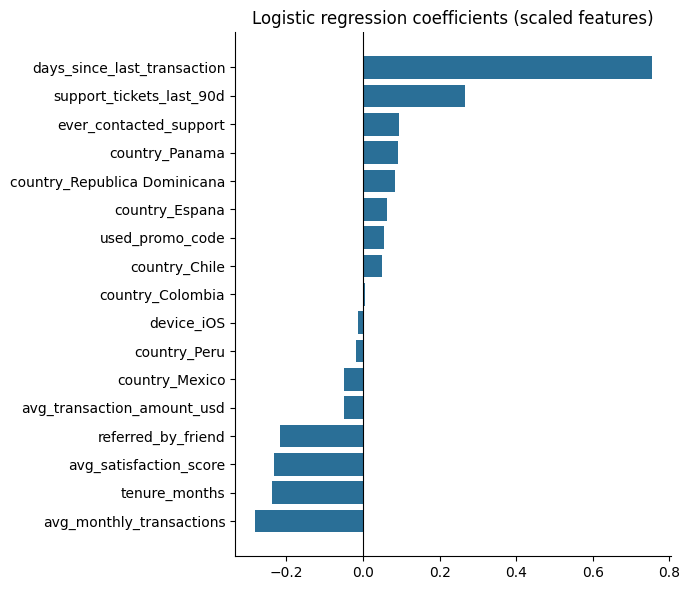

In [10]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(coef_df["feature"], coef_df["coefficient"], color="#2a6f97")
ax.set_title("Logistic regression coefficients (scaled features)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


Reading the coefficients: `days_since_last_transaction` and `support_tickets_last_90d` push churn probability up, while `tenure_months`, `avg_monthly_transactions` and `referred_by_friend` push it down. That matches what the boxplots suggested in the EDA section, which is a good sign, the model isn't picking up anything surprising or hard to explain.

## 5. Random Forest

A tree-based model usually performs better on this kind of tabular data with non-linear effects and doesn't need feature scaling. I'm also using `class_weight="balanced"` here for the same imbalance reason.

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["Not churned", "Churned"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))


              precision    recall  f1-score   support

 Not churned       0.88      0.74      0.80      1233
     Churned       0.31      0.55      0.40       267

    accuracy                           0.71      1500
   macro avg       0.60      0.65      0.60      1500
weighted avg       0.78      0.71      0.73      1500

ROC-AUC: 0.715


## 6. Comparing the two models

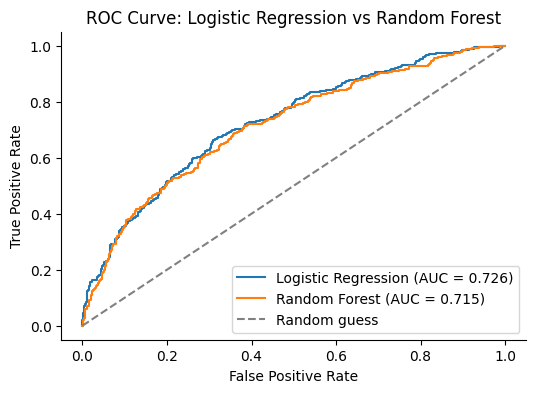

In [12]:
fig, ax = plt.subplots()
for name, proba in [("Logistic Regression", y_proba_log), ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: Logistic Regression vs Random Forest")
ax.legend()
plt.show()


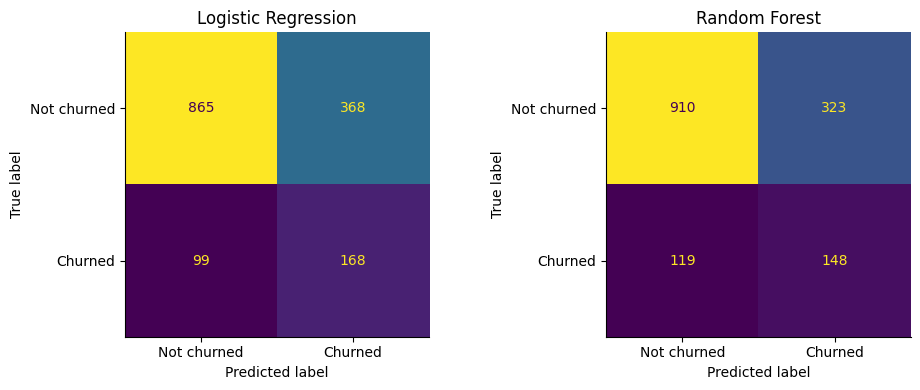

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [("Logistic Regression", y_pred_log), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not churned", "Churned"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


Interestingly, the untuned Random Forest does *not* beat the simpler Logistic Regression here on ROC-AUC (0.715 vs 0.726). That's a useful reminder: a more complex model isn't automatically better, especially without hyperparameter tuning. I'm keeping both models in the comparison rather than only reporting whichever one happened to win, since knowing when the simple model is competitive is itself a useful finding, not a failure of the exercise.

Looking at the confusion matrices: both models catch a meaningful share of churners, at the cost of some false positives (customers flagged as at-risk who wouldn't have churned). In a real retention program, that trade-off is usually fine, since a false positive just means an unnecessary retention offer, while a false negative means losing a customer with no intervention at all. If the retention offer were expensive, I'd want to move the classification threshold to trade some recall for precision, which is where the precision-recall curve below comes in.

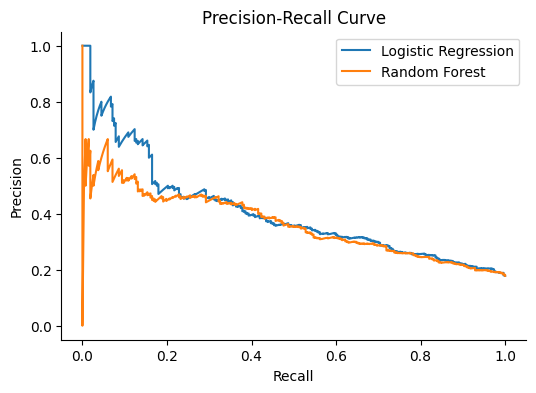

In [14]:
fig, ax = plt.subplots()
for name, proba in [("Logistic Regression", y_proba_log), ("Random Forest", y_proba_rf)]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ax.plot(recall, precision, label=name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
plt.show()


## 7. Feature importance and retention insights

This is the part that turns a model into something the retention team can act on.

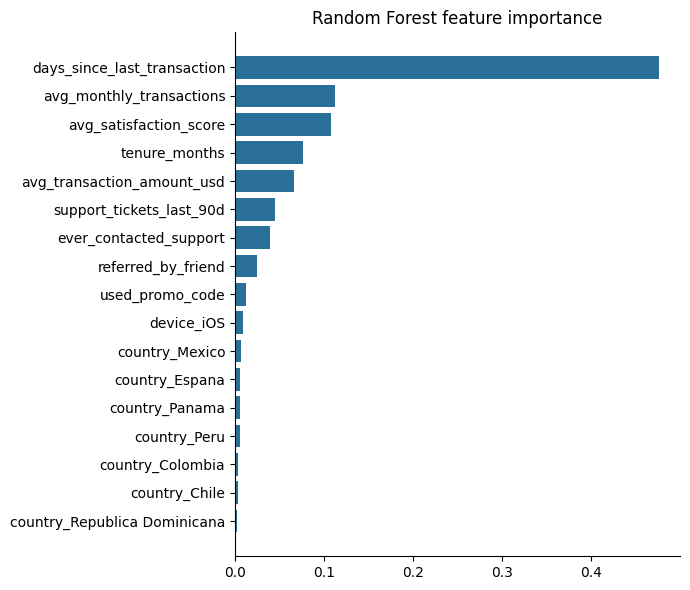

,feature,importance
3,days_since_last_transaction,0.475819
1,avg_monthly_transactions,0.112374
5,avg_satisfaction_score,0.107651
0,tenure_months,0.075859
2,avg_transaction_amount_usd,0.065924
4,support_tickets_last_90d,0.045343
8,ever_contacted_support,0.039264
7,referred_by_friend,0.024839
6,used_promo_code,0.011933
16,device_iOS,0.009305


In [15]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#2a6f97")
ax.set_title("Random Forest feature importance")
plt.tight_layout()
plt.show()

importance_df


**Top drivers of churn risk, in order:**
1. `days_since_last_transaction` — by far the strongest signal. This is the classic recency effect: the longer since the last transfer, the higher the risk.
2. `support_tickets_last_90d` and `ever_contacted_support` — customers who needed support are more likely to churn, which suggests unresolved friction is a real churn driver, not just a side effect of it.
3. `tenure_months` and `avg_monthly_transactions` — newer, less frequent customers are more at risk, which fits a typical onboarding/engagement story.

**Retention recommendations based on this:**
- Trigger a re-engagement flow (push notification, targeted offer) once a customer passes a `days_since_last_transaction` threshold, before they fully churn, rather than waiting for the 60-day churn definition to trigger after the fact.
- Treat a support ticket as a retention risk signal, not just an operational one: route customers with recent tickets into a follow-up satisfaction check.
- Focus retention effort on newer customers with low transaction frequency, since tenure and engagement are protective and their absence is a real risk factor.


## 8. Limitations and what I'd improve with more experience

- I used a single random train/test split. For a churn model that will run in production, I'd want a **time-based split** instead (train on older customers, test on more recent ones), since a random split can leak information across time in ways a churn model in the real world won't have access to.
- I didn't tune hyperparameters (tree depth, number of estimators, regularization strength); I'd normally do this with cross-validation and a grid or random search rather than picking reasonable-looking defaults.
- For feature importance, I used the Random Forest's built-in `feature_importances_`, which is fast but has known biases (it favors high-cardinality features and doesn't show direction of effect). A more rigorous version of this would use permutation importance or SHAP values, which also explain individual predictions, not just overall importance.
- I didn't explicitly handle the class imbalance beyond `class_weight="balanced"`; techniques like SMOTE (synthetic oversampling of the minority class) are worth comparing against, especially if recall on the churned class needs to be higher.
- The business recommendations here are qualitative. A more complete version would size the expected impact: for example, estimating how many customers are in the "high risk, still time to intervene" bucket for the recency threshold, and what a lift in retention there would be worth.
